In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry import Polygon
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# ML - реальные данные

In [3]:
gdf = gpd.read_parquet('data/blocks_indicator.parquet').to_crs(32636)
gdf.head()


,id,geometry,territory_id,name,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Средняя доступность до центра федерального округа,Социальное обеспечение (базовое),Социальное обеспечение (базовое+),Социальное обеспечение (комфорт),Количество объектов инженерной инфраструктуры,"Количество электростанций (ТЭС, АЭС и пр.)",Количество больших водозаборов,Количество очистительных сооружений,Количество крупных водохранилищ,Количество газораспределительных станций
0,0,"POLYGON ((570883.045 6596529.946, 570883.081 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"POLYGON ((570987.035 6596464.499, 570987.085 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,"POLYGON ((572676.73 6596606.982, 572676.701 65...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,"POLYGON ((583242.895 6595451.954, 583243.013 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,"POLYGON ((582405.498 6595459.455, 582405.614 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Адаптируем статью

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

# Список типов землепользования
land_use_types = ['residential', 'recreation', 'special', 'industrial', 
                 'agriculture', 'transport', 'business', 'basic',
                 'residential_individual', 'residential_lowrise', 
                 'residential_midrise', 'residential_multistorey', 'mixed_use']

def calculate_investment_return(gdf, land_use_type, scaler=None):
    """
    Рассчитывает инвестиционную привлекательность для переданного gdf с заданным типом землепользования.
    
    Args:
        gdf (GeoDataFrame): Входной GeoDataFrame с данными.
        land_use_type (str): Тип землепользования из land_use_types.
        scaler (MinMaxScaler, optional): Обученный scaler для нормализации. Если None, будет создан новый.
    
    Returns:
        GeoDataFrame: Исходный gdf с добавленными столбцами LandUseType и InvestmentReturn.
    """
    if land_use_type not in land_use_types:
        raise ValueError(f"land_use_type должен быть одним из: {land_use_types}")

    # 1. Очистка данных
    df = gdf.drop_duplicates().fillna(0)
    if df.empty:
        raise ValueError("gdf пустой после очистки.")

    # 2. Копируем исходные данные для нормализации
    df_normalized = df.copy()

    # Удаляем нечисловые столбцы для нормализации
    numeric_cols = df_normalized.select_dtypes(include=[np.number]).columns
    non_numeric_cols = [col for col in df_normalized.columns if col not in numeric_cols]
    df_normalized = df_normalized.drop(columns=non_numeric_cols, errors='ignore')

    # 3. Нормализация признаков только для вычислений
    numeric_features = [col for col in df_normalized.columns if col != 'InvestmentReturn']
    if scaler is None:
        scaler = MinMaxScaler()
        df_normalized[numeric_features] = scaler.fit_transform(df_normalized[numeric_features])
    else:
        df_normalized[numeric_features] = scaler.transform(df_normalized[numeric_features])

    # 4. Расчет инвестиционной привлекательности с нормализованными данными
    df['InvestmentReturn'] = (
        # Демография и урбанизация (15%)
        0.03 * df_normalized['Численность населения'] +
        0.03 * df_normalized['Степень урбанизации территории'] +
        0.03 * np.log1p(df_normalized['Плотность улично-дорожной сети']) +
        0.03 * df_normalized['Связанность населенных пунктов'] +
        0.03 * df_normalized['Обеспеченность общественными пространства'] +
        
        # Транспортная инфраструктура (25%)
        0.03 * df_normalized['Протяженность дорог федерального значения'] +
        0.03 * df_normalized['Протяженность дорог регионального значения'] +
        0.03 * df_normalized['Протяженность дорог местного значения'] +
        0.02 * df_normalized['Количество маршрутов общественного транспорта'] +
        0.02 * df_normalized['Количество остановок общественного транспорта'] +
        0.02 * df_normalized['Общая протяженность железнодорожных путей'] +
        0.02 * df_normalized['Количество остановок железнодорожного транспорта'] +
        0.02 * (1 - df_normalized['Средняя доступность до федеральных транспортных магистралей']) +
        0.02 * (1 - df_normalized['Средняя доступность остановок железнодорожного транспорта']) +
        0.02 * df_normalized['Количество международных аэропортов'] +
        0.02 * df_normalized['Количество аэропортов местного значения'] +
        0.02 * df_normalized['Количество портов'] +
        
        # Социальная инфраструктура (25%)
        0.02 * df_normalized['Обеспеченность детскими садами'] +
        0.02 * df_normalized['Обеспеченность школами'] +
        0.02 * df_normalized['Обеспеченность центрами детского творчества'] +
        0.02 * df_normalized['Обеспеченность школами искусств'] +
        0.02 * df_normalized['Обеспеченность ФАП / амбулаториями'] +
        0.02 * df_normalized['Обеспеченность аптеками'] +
        0.02 * df_normalized['Обеспеченность поликлиниками / центрами семейной медицины'] +
        0.02 * df_normalized['Обеспеченность участковыми больницами'] +
        0.02 * df_normalized['Обеспеченность городскими больницами (д/в)'] +
        0.01 * df_normalized['Обеспеченность детскими площадками'] +
        0.01 * df_normalized['Обеспеченность скверами / бульварами / лесопарками'] +
        0.01 * df_normalized['Обеспеченность парками'] +
        0.01 * df_normalized['Обеспеченность парками развлечений'] +
        0.01 * df_normalized['Социальное обеспечение (комфорт)'] +
        
        # Экономические факторы (20%)
        0.02 * df_normalized['Обеспеченность продуктовыми магазинами'] +
        0.02 * df_normalized['Обеспеченность хозяйственными магазинами'] +
        0.02 * df_normalized['Обеспеченность ТЦ / супермаркетами'] +
        0.02 * df_normalized['Обеспеченность ТРК / гипермаркетами'] +
        0.02 * df_normalized['Обеспеченность профильными магазинами'] +
        0.02 * df_normalized['Обеспеченность кафе / кофейнями'] +
        0.02 * df_normalized['Обеспеченность барами / ресторанами'] +
        0.02 * df_normalized['Обеспеченность коммерческими клиниками'] +
        0.02 * df_normalized['Обеспеченность отделениями банков'] +
        0.02 * df_normalized['Количество автозаправочных станций'] +
        
        # Связанность и доступность (15%)
        0.03 * df_normalized['Связанность'] +
        0.02 * (1 - df_normalized['Средняя доступность до центра региона']) +
        0.02 * (1 - df_normalized['Средняя доступность до федерального центра']) +
        0.02 * (1 - df_normalized['Средняя доступность до центра федерального округа']) +
        0.02 * df_normalized['Связанность общественным транспортом'] +
        0.02 * df_normalized['Количество объектов инженерной инфраструктуры'] +
        0.02 * df_normalized['Количество электростанций (ТЭС, АЭС и пр.)'] +
        
        # Случайный шум
        np.random.normal(0, 0.5, len(df))
    )

    # 5. Добавляем тип землепользования в исходный gdf
    df['LandUseType'] = land_use_type

    return df

def prepare_for_training(gdf):
    """
    Подготавливает данные из gdf для обучения XGBoost.
    
    Args:
        gdf (GeoDataFrame): Входной GeoDataFrame с данными, включая LandUseType и InvestmentReturn.
    
    Returns:
        tuple: (X_train, X_test, y_train, y_test, scaler)
    """
    # 1. Очистка данных
    df = gdf.drop_duplicates().fillna(0)
    if df.empty:
        raise ValueError("gdf пустой после очистки.")
    if 'InvestmentReturn' not in df.columns:
        raise ValueError("В gdf отсутствует столбец InvestmentReturn.")
    if 'LandUseType' not in df.columns:
        raise ValueError("В gdf отсутствует столбец LandUseType.")

    # 2. One-Hot Encoding для LandUseType
    df = pd.get_dummies(df, columns=['LandUseType'], prefix='LandUse')

    # Сохраняем id и territory_id
    id_columns = [col for col in df.columns if col.lower() in ['id', 'territory_id']]

    # Удаляем все нечисловые столбцы, кроме id_columns и LandUse
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    non_numeric_cols = [col for col in df.columns if col not in numeric_cols and col not in id_columns and not col.startswith('LandUse')]
    df = df.drop(columns=non_numeric_cols, errors='ignore')
    df = df.drop(columns=['geometry'], errors='ignore')

    # 3. Нормализация признаков
    scaler = MinMaxScaler()
    numeric_features = [col for col in df.columns if col not in id_columns and not col.startswith('LandUse') and col != 'InvestmentReturn']
    df[numeric_features] = scaler.fit_transform(df[numeric_features])

    # 4. Разделение данных для обучения
    df['Stratum'] = pd.qcut(df['InvestmentReturn'], q=4, labels=False, duplicates='drop')
    X = df.drop(['InvestmentReturn', 'Stratum'], axis=1)
    y = df['InvestmentReturn']

    # Преобразование в numpy.ndarray
    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y.values,
        train_size=0.75,
        stratify=df['Stratum'],
        random_state=42
    )

    return X_train, X_test, y_train, y_test, scaler

# Пример использования:
# 1. Расчет InvestmentReturn для оригинального gdf
# gdf - ваш оригинальный GeoDataFrame
df_with_returns = calculate_investment_return(gdf, 'residential')
print("Инвестиционная привлекательность для оригинального gdf:")
print(df_with_returns[['LandUseType', 'InvestmentReturn']])

# 2. Подготовка данных для обучения
X_train, X_test, y_train, y_test, scaler = prepare_for_training(df_with_returns)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Обучение модели
model = XGBRegressor()
model.fit(X_train, y_train)

# # 3. Расчет для нового gdf_new (с одной строкой)
# # gdf_new - ваш новый GeoDataFrame с одной строкой
# result = calculate_investment_return(gdf_new, 'residential', scaler)
# print("Инвестиционная привлекательность для нового gdf:")
# print(result[['LandUseType', 'InvestmentReturn']])


Инвестиционная привлекательность для оригинального gdf:
       LandUseType  InvestmentReturn
0      residential         -0.684903
1      residential          0.871188
2      residential         -0.264154
3      residential          0.564478
4      residential         -0.092975
...            ...               ...
34642  residential          1.090865
34643  residential          0.487361
34644  residential         -0.685898
34645  residential          0.529959
34646  residential         -0.186078

[34647 rows x 2 columns]
X_train shape: (25985, 82)
X_test shape: (8662, 82)
y_train shape: (25985,)
y_test shape: (8662,)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [11]:
df_with_returns

,id,geometry,territory_id,name,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Социальное обеспечение (базовое+),Социальное обеспечение (комфорт),Количество объектов инженерной инфраструктуры,"Количество электростанций (ТЭС, АЭС и пр.)",Количество больших водозаборов,Количество очистительных сооружений,Количество крупных водохранилищ,Количество газораспределительных станций,InvestmentReturn,LandUseType
0,0,"POLYGON ((570883.045 6596529.946, 570883.081 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.684903,residential
1,1,"POLYGON ((570987.035 6596464.499, 570987.085 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.871188,residential
2,2,"POLYGON ((572676.73 6596606.982, 572676.701 65...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.264154,residential
3,3,"POLYGON ((583242.895 6595451.954, 583243.013 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.564478,residential
4,4,"POLYGON ((582405.498 6595459.455, 582405.614 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.092975,residential
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34642,34645,"POLYGON ((279466.739 6647657.982, 279466.837 6...",1267.0,город Сосновый бор,63462.0,66.50,0.000,0.000000,0.000000,0.00,...,0.0,0.0,6.0,0.0,0.0,5.0,1.0,0.0,1.090865,residential
34643,34646,"POLYGON ((279467.148 6647660.126, 279467.165 6...",1267.0,город Сосновый бор,63462.0,66.50,0.000,0.000000,0.000000,0.00,...,0.0,0.0,6.0,0.0,0.0,5.0,1.0,0.0,0.487361,residential
34644,34647,"POLYGON ((279542.296 6648001.072, 279542.336 6...",1267.0,город Сосновый бор,63462.0,66.50,0.000,0.000000,0.000000,0.00,...,0.0,0.0,6.0,0.0,0.0,5.0,1.0,0.0,-0.685898,residential
34645,34648,"POLYGON ((279625.847 6648207.164, 279625.886 6...",1267.0,город Сосновый бор,63462.0,66.50,0.000,0.000000,0.000000,0.00,...,0.0,0.0,6.0,0.0,0.0,5.0,1.0,0.0,0.529959,residential


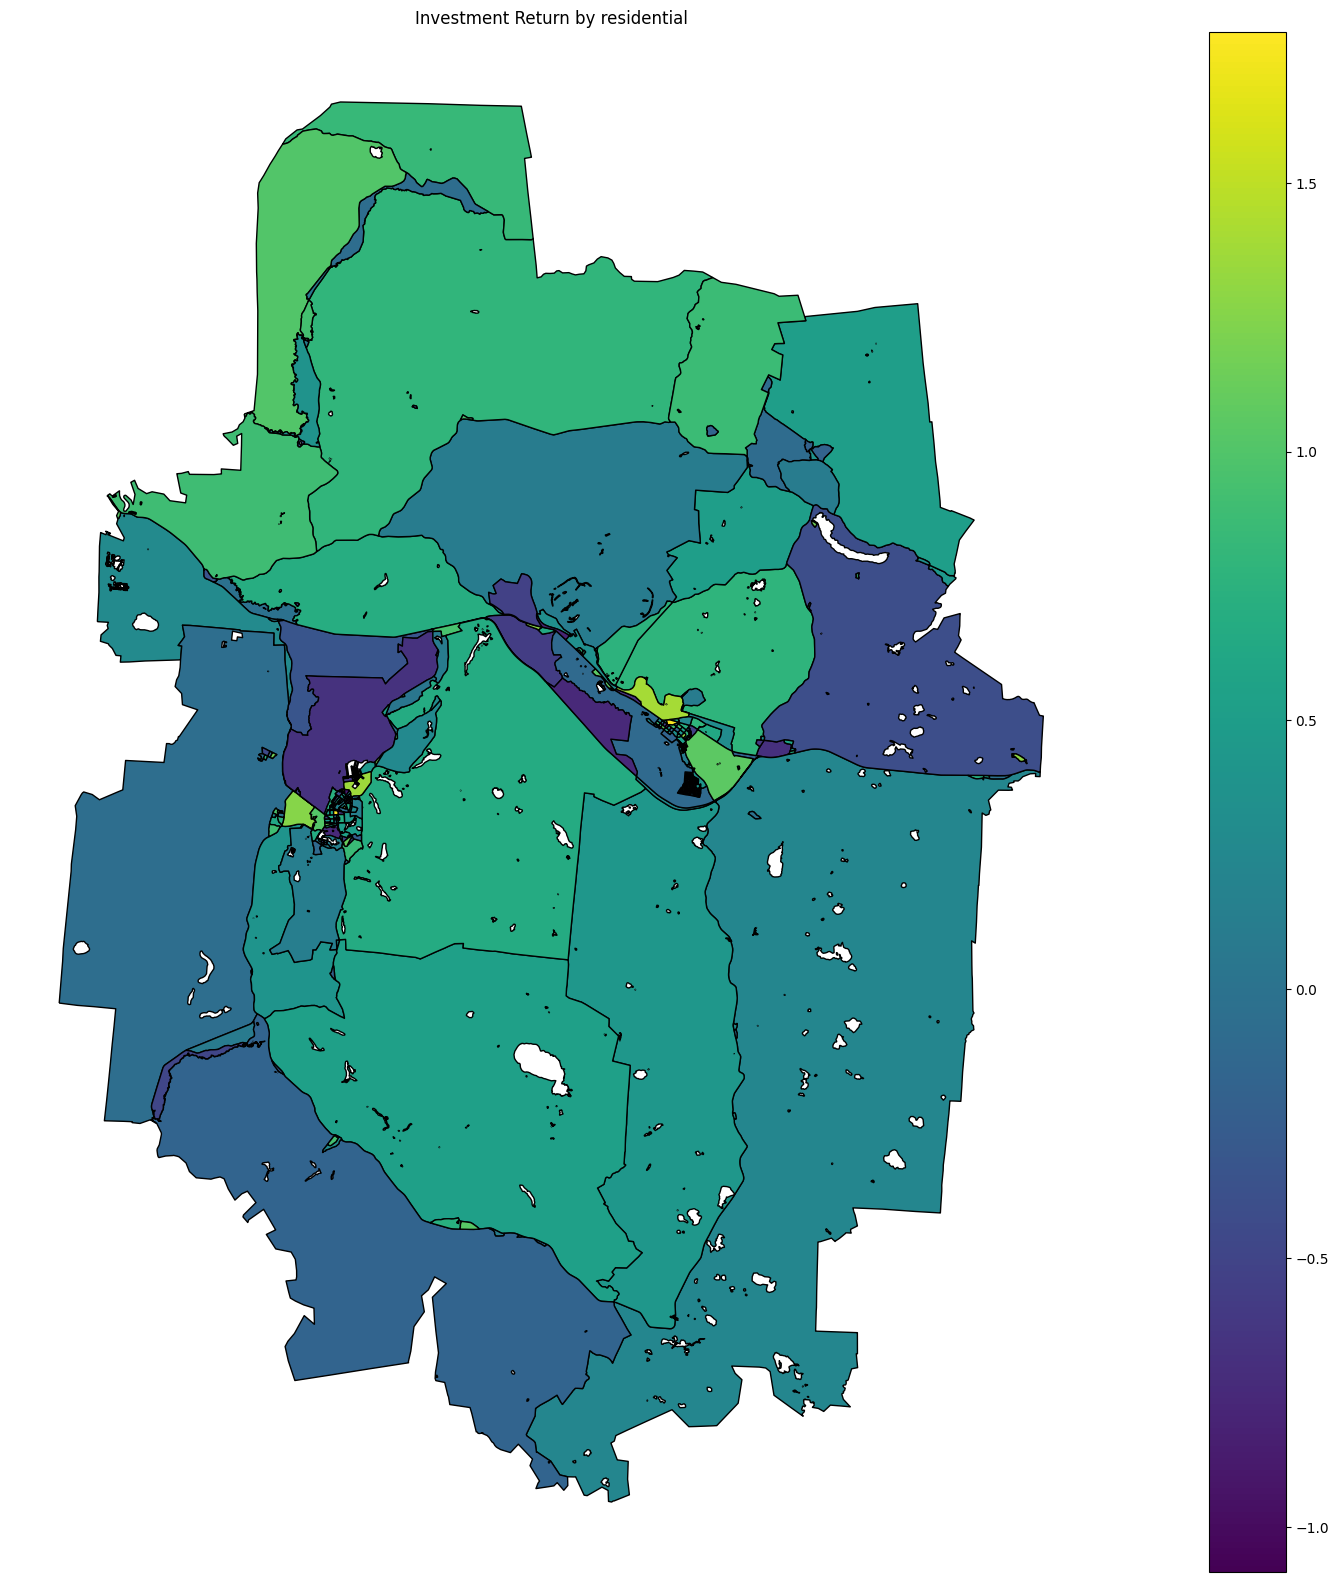

In [19]:

df_with_returns.head(500).plot(column='InvestmentReturn',
         cmap='viridis',           # или 'OrRd', 'coolwarm', 'plasma', см. ниже для других вариантов
         legend=True,
         edgecolor='black',
         figsize=(30, 20))
plt.title('Investment Return by residential')  # или другая подходящая подпись
plt.axis('off')
plt.show()

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import json

def visualize_transport_provision(result, road_gdf):
    """
    Визуализирует обеспеченность транспортной инфраструктурой и отображает дороги.
    
    :param result: GeoDataFrame с рассчитанными индексами обеспеченности
    :param road_gdf: GeoDataFrame с дорогами
    """
    fig, ax = plt.subplots(figsize=(50, 20))
    
    # Ограничиваем влияние выбросов, используя 1-й и 99-й процентиль
    vmin, vmax = np.percentile(result['transport_provision_index'], [1, 100])

    # Отображение карты с улучшенной цветовой шкалой
    result.plot(column='transport_provision_index', cmap='Blues', linewidth=0.5, 
                edgecolor='black', legend=True, ax=ax, vmin=vmin, vmax=vmax)
    
    # Преобразуем properties из строки JSON в словарь, если нужно
    if isinstance(road_gdf['properties'].iloc[0], str):  
        road_gdf['properties'] = road_gdf['properties'].apply(json.loads)

    # Определяем ширину дорог в зависимости от свойства "reg"
    road_gdf['width'] = road_gdf['properties'].apply(lambda x: 1.5 if x.get('reg') == 1 else 0.6)

    # Визуализация дорог с прозрачностью 60%
    road_gdf.plot(ax=ax, color='black', linewidth=road_gdf['width'], alpha=0.7)
    
    # Убираем рамку с координатами
    ax.set_axis_off()
    
    # Добавляем заголовок
    plt.title("Обеспеченность транспортной инфраструктурой", fontsize=14)
    plt.show()

# Вызов функции
visualize_transport_provision(result, road_gdf)


NameError: name 'result' is not defined

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats import skew
from xgboost import XGBRegressor

# 1. Очистка данных (Data Cleaning)
def clean_data(df):
    # Удаление дубликатов
    df = df.drop_duplicates()
    
    # Удаление строк с пропущенными значениями в целевой переменной
    df = df.dropna(subset=['InvestmentReturn'])
    
    # Заполнение пропущенных значений в признаках (как в вашем оригинальном коде)
    for col in df.columns:
        if col != 'LandUseType' and col != 'InvestmentReturn':
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)
            df[col] = df[col].fillna(df[col].median())
            df[col] = df[col].clip(lower=0, upper=1e6)
    
    return df

# 2. Кодирование категориальных переменных (One-Hot Encoding)
def encode_categorical(df):
    # Применяем One-Hot Encoding к LandUseType
    df_encoded = pd.get_dummies(df, columns=['LandUseType'], prefix='LandUse')
    return df_encoded

# 3. Масштабирование признаков (Feature Scaling)
def scale_features(df, method='minmax'):
    features = [col for col in df.columns if col != 'InvestmentReturn' and not col.startswith('LandUse')]
    X = df[features]
    
    if method == 'minmax':
        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X)
    else:  # standardization
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    
    df_scaled = pd.DataFrame(X_scaled, columns=features, index=df.index)
    # Добавляем обратно закодированные категориальные переменные и целевую переменную
    df_scaled = pd.concat([
        df_scaled,
        df[[col for col in df.columns if col.startswith('LandUse')]],
        df['InvestmentReturn']
    ], axis=1)
    
    return df_scaled, scaler

# 4. Стратифицированное разделение данных (Stratified Sampling)
def stratified_split(df, target='InvestmentReturn', train_size=0.75):
    # Проверяем скошенность распределения целевой переменной
    skewness = skew(df[target].dropna())
    print(f"Skewness of target variable: {skewness}")
    
    # Создаем страты на основе квантилей
    n_bins = 5  # количество страт
    df['strata'] = pd.qcut(df[target], q=n_bins, labels=False, duplicates='drop')
    
    # Разделяем данные с учетом страт
    X = df.drop(columns=[target, 'strata'])
    y = df[target]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        train_size=train_size,
        stratify=df['strata'],
        random_state=42
    )
    
    # Удаляем временный столбец strata из исходного датафрейма
    df.drop(columns=['strata'], inplace=True)
    
    return X_train, X_test, y_train, y_test

# Основной процесс препроцессинга
def preprocess_data(df):
    # Шаг 1: Очистка данных
    df_cleaned = clean_data(df)
    print("Data cleaning completed. Shape:", df_cleaned.shape)
    
    # Шаг 2: Кодирование категориальных переменных
    df_encoded = encode_categorical(df_cleaned)
    print("Categorical encoding completed. Shape:", df_encoded.shape)
    
    # Шаг 3: Масштабирование признаков (сравниваем оба метода)
    df_minmax, scaler_minmax = scale_features(df_encoded, method='minmax')
    df_standard, scaler_standard = scale_features(df_encoded, method='standard')
    
    # Шаг 4: Стратифицированное разделение
    X_train_mm, X_test_mm, y_train_mm, y_test_mm = stratified_split(df_minmax)
    X_train_std, X_test_std, y_train_std, y_test_std = stratified_split(df_standard)
    
    return {
        'minmax': (X_train_mm, X_test_mm, y_train_mm, y_test_mm, scaler_minmax),
        'standard': (X_train_std, X_test_std, y_train_std, y_test_std, scaler_standard)
    }

# Применение препроцессинга
# Предполагается, что df уже создан вашим предыдущим кодом
preprocessed_data = preprocess_data(df)

# Доступ к данным с разными видами масштабирования
X_train_mm = preprocessed_data['minmax'][0]
X_test_mm = preprocessed_data['minmax'][1]
y_train_mm = preprocessed_data['minmax'][2]
y_test_mm = preprocessed_data['minmax'][3]

X_train_std = preprocessed_data['standard'][0]
X_test_std = preprocessed_data['standard'][1]
y_train_std = preprocessed_data['standard'][2]
y_test_std = preprocessed_data['standard'][3]

Data cleaning completed. Shape: (450411, 81)
Categorical encoding completed. Shape: (450411, 93)
Skewness of target variable: 0.7208846079686582
Skewness of target variable: 0.7208846079686582


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# Предполагается, что preprocess_data из предыдущего кода уже выполнен
# Используем данные с MinMax масштабированием как базовый вариант
X_train = preprocessed_data['minmax'][0]
X_test = preprocessed_data['minmax'][1]
y_train = preprocessed_data['minmax'][2]
y_test = preprocessed_data['minmax'][3]

# 1. Очистка целевой переменной
y_train = y_train.replace([np.inf, -np.inf], np.nan).dropna()
y_test = y_test.replace([np.inf, -np.inf], np.nan).dropna()
y_train = y_train.clip(lower=-100, upper=100)
y_test = y_test.clip(lower=-100, upper=100)

# Убедимся, что X и y имеют одинаковые индексы
X_train = X_train.loc[y_train.index]
X_test = X_test.loc[y_test.index]

# 2. Отбор признаков с использованием XGBoost
def select_features(X_train, y_train, X_test, n_features=18):
    # Базовая модель XGBoost для оценки важности признаков
    xgb_selector = XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.26,
        random_state=42
    )
    selector = SelectFromModel(xgb_selector, max_features=n_features, prefit=False)
    selector.fit(X_train, y_train)
    
    # Получаем выбранные признаки
    selected_features = X_train.columns[selector.get_support()].tolist()
    print(f"Selected {len(selected_features)} features: {selected_features}")
    
    return X_train[selected_features], X_test[selected_features], selected_features

# Отбираем топ-18 признаков (как в статье для XGBoost)
X_train_selected, X_test_selected, selected_features = select_features(X_train, y_train, X_test, n_features=18)

# 3. Настройка гиперпараметров XGBoost с помощью GridSearchCV
param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.1, 0.3, 0.5],
    'alpha': [0.1, 1.0, 10.0],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_selected, y_train)

# Лучшая модель
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# 4. Оценка модели
def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Предсказания
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Метрики
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
    mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
    nrmse_train = np.sqrt(np.mean((y_train - y_train_pred) ** 2)) / (y_train.max() - y_train.min())
    nrmse_test = np.sqrt(np.mean((y_test - y_test_pred) ** 2)) / (y_test.max() - y_test.min())
    
    print("\nTraining Performance:")
    print(f"R²: {r2_train:.3f}")
    print(f"MAPE: {mape_train:.3f}")
    print(f"nRMSE: {nrmse_train:.3f}")
    
    print("\nTest Performance:")
    print(f"R²: {r2_test:.3f}")
    print(f"MAPE: {mape_test:.3f}")
    print(f"nRMSE: {nrmse_test:.3f}")
    
    return {
        'r2_train': r2_train, 'r2_test': r2_test,
        'mape_train': mape_train, 'mape_test': mape_test,
        'nrmse_train': nrmse_train, 'nrmse_test': nrmse_test
    }

# Оцениваем лучшую модель
metrics = evaluate_model(best_model, X_train_selected, X_test_selected, y_train, y_test)

# 5. Важность признаков
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': best_model.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)

# 6. Сравнение с базовой моделью (без настройки)
base_model = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.3, alpha=1.0, random_state=42)
base_model.fit(X_train_selected, y_train)
print("\nBaseline Model Performance:")
base_metrics = evaluate_model(base_model, X_train_selected, X_test_selected, y_train, y_test)

Selected 11 features: ['Population', 'LandUse_agriculture', 'LandUse_basic', 'LandUse_business', 'LandUse_industrial', 'LandUse_mixed_use', 'LandUse_recreation', 'LandUse_residential', 'LandUse_residential_midrise', 'LandUse_residential_multistorey', 'LandUse_special']
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters: {'alpha': 10.0, 'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 1.0}

Training Performance:
R²: 0.689
MAPE: 1.404
nRMSE: 0.066

Test Performance:
R²: 0.684
MAPE: 1.614
nRMSE: 0.067

Feature Importance:
                            Feature  Importance
0                        Population    0.162182
3                  LandUse_business    0.156765
5                 LandUse_mixed_use    0.152319
2                     LandUse_basic    0.150984
10                  LandUse_special    0.102278
6                LandUse_recreation    0.085648
9   LandUse_residential_multistorey    0.067681
1             

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# Используем данные с MinMax масштабированием
X_train = preprocessed_data['minmax'][0]
X_test = preprocessed_data['minmax'][1]
y_train = preprocessed_data['minmax'][2]
y_test = preprocessed_data['minmax'][3]

# 1. Очистка и преобразование целевой переменной
y_train = y_train.replace([np.inf, -np.inf], np.nan).dropna()
y_test = y_test.replace([np.inf, -np.inf], np.nan).dropna()
y_train = y_train.clip(lower=-100, upper=100)
y_test = y_test.clip(lower=-100, upper=100)

# Логарифмическое преобразование
y_train_log = np.log1p(y_train - y_train.min() + 1)
y_test_log = np.log1p(y_test - y_test.min() + 1)

# Убедимся, что X и y имеют одинаковые индексы
X_train = X_train.loc[y_train.index]
X_test = X_test.loc[y_test.index]

# 2. Используем все признаки без отбора
X_train_selected = X_train
X_test_selected = X_test
selected_features = X_train.columns.tolist()
print(f"Using all {len(selected_features)} features out of {X_train.shape[1]}")

# 3. Настройка гиперпараметров XGBoost с помощью GridSearchCV
param_grid = {
    'n_estimators': [300, 500, 1000],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.05, 0.1, 0.3, 0.5],
    'alpha': [0.1, 1.0, 10.0],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb = XGBRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Обучение на логарифмически преобразованной целевой переменной
grid_search.fit(X_train_selected, y_train_log)

# Лучшая модель
best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

# 4. Оценка модели с обратным преобразованием
def evaluate_model(model, X_train, X_test, y_train, y_test, y_train_log, y_test_log):
    # Предсказания в логарифмическом масштабе
    y_train_pred_log = model.predict(X_train)
    y_test_pred_log = model.predict(X_test)
    
    # Обратное преобразование в исходный масштаб
    y_train_pred = np.expm1(y_train_pred_log) + y_train.min() - 1
    y_test_pred = np.expm1(y_test_pred_log) + y_test.min() - 1
    
    # Метрики
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
    mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
    nrmse_train = np.sqrt(np.mean((y_train - y_train_pred) ** 2)) / (y_train.max() - y_train.min())
    nrmse_test = np.sqrt(np.mean((y_test - y_test_pred) ** 2)) / (y_test.max() - y_test.min())
    
    print("\nTraining Performance:")
    print(f"R²: {r2_train:.3f}")
    print(f"MAPE: {mape_train:.3f}")
    print(f"nRMSE: {nrmse_train:.3f}")
    
    print("\nTest Performance:")
    print(f"R²: {r2_test:.3f}")
    print(f"MAPE: {mape_test:.3f}")
    print(f"nRMSE: {nrmse_test:.3f}")
    
    return {
        'r2_train': r2_train, 'r2_test': r2_test,
        'mape_train': mape_train, 'mape_test': mape_test,
        'nrmse_train': nrmse_train, 'nrmse_test': nrmse_test
    }

# Оцениваем лучшую модель
metrics = evaluate_model(best_model, X_train_selected, X_test_selected, y_train, y_test, y_train_log, y_test_log)

# 5. Важность признаков
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': best_model.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance.head(20))  # Показываем топ-20 признаков

# 6. Сравнение с базовой моделью
base_model = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.3, alpha=1.0, random_state=42)
base_model.fit(X_train_selected, y_train_log)
print("\nBaseline Model Performance:")
base_metrics = evaluate_model(base_model, X_train_selected, X_test_selected, y_train, y_test, y_train_log, y_test_log)

Using all 92 features out of 92
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x1306dabf0>>
Traceback (most recent call last):
  File "/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/xgboost/core.py", line 582, in _next_wrapper
    def _next_wrapper(self, this: None) -> int:  # pylint: disable=unused-argument
KeyboardInterrupt: 
Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x135a649d0>>
Traceback (most recent call last):
  File "/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/xgboost/core.py", line 582, in _next_wrapper
    def _next_wrapper(self, this: None) -> int:  # pylint: disable=unused-argument
KeyboardInterrupt: 


KeyboardInterrupt: 

In [13]:
X_train

,Population,Urbanization,HighwayAccessibility,RegionCenterAccessibility,Connectivity,SettlementConnectivity,RoadDensity,FederalRoads,RegionalRoads,LocalRoads,...,LandUse_industrial,LandUse_mixed_use,LandUse_recreation,LandUse_residential,LandUse_residential_individual,LandUse_residential_lowrise,LandUse_residential_midrise,LandUse_residential_multistorey,LandUse_special,LandUse_transport
262537,0.031509,0.583838,1.008700e-05,0.192182,0.416176,0.000127,0.904781,0.000000,0.065366,0.247468,...,False,False,False,False,False,False,False,False,True,False
221782,0.160960,0.215217,1.534700e-05,0.072685,0.397323,0.000121,0.209798,0.000000,0.174054,0.279848,...,False,False,False,False,False,False,False,False,True,False
411481,0.005199,0.484341,6.875300e-05,0.444898,0.719540,0.000219,0.071513,0.000000,0.173580,0.032564,...,False,False,False,False,False,False,False,False,False,True
299927,0.120634,0.466783,1.245100e-05,0.200185,0.427168,0.000130,0.163967,0.085721,0.272205,0.941579,...,False,False,False,False,False,False,False,False,False,False
327506,0.024347,0.142725,1.631000e-06,0.188478,0.490699,0.000148,0.211379,0.183026,0.128581,0.398253,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250670,0.009115,0.438957,7.204600e-05,0.422313,0.537415,0.000164,0.034769,0.000000,0.161755,0.119395,...,False,False,False,False,False,False,False,False,False,False
93563,0.097838,0.550467,4.090000e-06,0.263197,0.445716,0.000136,0.721059,0.173006,0.040331,0.685995,...,False,False,False,False,False,False,False,False,True,False
165780,0.136939,0.000000,1.787000e-05,0.667107,0.839545,0.000256,0.108258,0.000000,0.491411,0.839468,...,False,False,False,False,False,False,False,False,False,False
57141,0.080873,0.485882,3.347700e-05,0.310359,0.482643,0.000147,0.034374,0.229339,0.177448,0.547725,...,False,False,False,False,False,False,False,False,False,False


In [ ]:

# Убираем экстремальные значения в целевой переменной
df['InvestmentReturn'] = df['InvestmentReturn'].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['InvestmentReturn'])
df['InvestmentReturn'] = df['InvestmentReturn'].clip(lower=-100, upper=100)  # Ограничиваем разумный диапазон

# Подготовка данных для обучения
df['LandUseType'] = le.transform(df['LandUseType'])
X = df.drop('InvestmentReturn', axis=1)
y = df['InvestmentReturn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Обучение модели
model = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.3, alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Оценка модели
print(f"Точность на обучающей выборке (R²): {model.score(X_train, y_train):.3f}")
print(f"Точность на тестовой выборке (R²): {model.score(X_test, y_test):.3f}")

Точность на обучающей выборке (R²): 0.687
Точность на тестовой выборке (R²): 0.691


In [18]:
def predict_investment_potential(territory_idx):
    territory_data = gdf.iloc[territory_idx]
    predictions = {}
    for land_type in land_use_types:
        input_data = pd.DataFrame([{
            'LandUseType': le.transform([land_type])[0],
            'Population': features['Population'].iloc[territory_idx],
            'Urbanization': features['Urbanization'].iloc[territory_idx],
            'HighwayAccessibility': features['HighwayAccessibility'].iloc[territory_idx],
            'RegionCenterAccessibility': features['RegionCenterAccessibility'].iloc[territory_idx],
            'Connectivity': features['Connectivity'].iloc[territory_idx],
            'SettlementConnectivity': features['SettlementConnectivity'].iloc[territory_idx],
            'RoadDensity': features['RoadDensity'].iloc[territory_idx],
            'FederalRoads': features['FederalRoads'].iloc[territory_idx],
            'RegionalRoads': features['RegionalRoads'].iloc[territory_idx],
            'LocalRoads': features['LocalRoads'].iloc[territory_idx],
            'PublicTransportRoutes': features['PublicTransportRoutes'].iloc[territory_idx],
            'PublicTransportStops': features['PublicTransportStops'].iloc[territory_idx],
            'GasStations': features['GasStations'].iloc[territory_idx],
            'GasStationAccessibility': features['GasStationAccessibility'].iloc[territory_idx],
            'RailwayLength': features['RailwayLength'].iloc[territory_idx],
            'RailwayStops': features['RailwayStops'].iloc[territory_idx],
            'RailwayAccessibility': features['RailwayAccessibility'].iloc[territory_idx],
            'IntAirports': features['IntAirports'].iloc[territory_idx],
            'LocalAirports': features['LocalAirports'].iloc[territory_idx],
            'IntAirportAccessibility': features['IntAirportAccessibility'].iloc[territory_idx],
            'LocalAirportAccessibility': features['LocalAirportAccessibility'].iloc[territory_idx],
            'Ports': features['Ports'].iloc[territory_idx],
            'Kindergartens': features['Kindergartens'].iloc[territory_idx],
            'Schools': features['Schools'].iloc[territory_idx],
            'ChildrenCenters': features['ChildrenCenters'].iloc[territory_idx],
            'ArtSchools': features['ArtSchools'].iloc[territory_idx],
            'MedicalPoints': features['MedicalPoints'].iloc[territory_idx],
            'Pharmacies': features['Pharmacies'].iloc[territory_idx],
            'Clinics': features['Clinics'].iloc[territory_idx],
            'LocalHospitals': features['LocalHospitals'].iloc[territory_idx],
            'CityHospitals': features['CityHospitals'].iloc[territory_idx],
            'CommercialClinics': features['CommercialClinics'].iloc[territory_idx],
            'GroceryStores': features['GroceryStores'].iloc[territory_idx],
            'HardwareStores': features['HardwareStores'].iloc[territory_idx],
            'ShoppingCenters': features['ShoppingCenters'].iloc[territory_idx],
            'PetStores': features['PetStores'].iloc[territory_idx],
            'Hypermarkets': features['Hypermarkets'].iloc[territory_idx],
            'SpecialtyStores': features['SpecialtyStores'].iloc[territory_idx],
            'Cafes': features['Cafes'].iloc[territory_idx],
            'Restaurants': features['Restaurants'].iloc[territory_idx],
            'FoodCourts': features['FoodCourts'].iloc[territory_idx],
            'CommunityHalls': features['CommunityHalls'].iloc[territory_idx],
            'CultureCenters': features['CultureCenters'].iloc[territory_idx],
            'Libraries': features['Libraries'].iloc[territory_idx],
            'ReligiousSites': features['ReligiousSites'].iloc[territory_idx],
            'Playgrounds': features['Playgrounds'].iloc[territory_idx],
            'Parks': features['Parks'].iloc[territory_idx],
            'PublicSpaces': features['PublicSpaces'].iloc[territory_idx],
            'LargeParks': features['LargeParks'].iloc[territory_idx],
            'AmusementParks': features['AmusementParks'].iloc[territory_idx],
            'DogParks': features['DogParks'].iloc[territory_idx],
            'WorkoutAreas': features['WorkoutAreas'].iloc[territory_idx],
            'FitnessCenters': features['FitnessCenters'].iloc[territory_idx],
            'SkateParks': features['SkateParks'].iloc[territory_idx],
            'SportsComplexes': features['SportsComplexes'].iloc[territory_idx],
            'DeliveryPoints': features['DeliveryPoints'].iloc[territory_idx],
            'Salons': features['Salons'].iloc[territory_idx],
            'HouseholdServices': features['HouseholdServices'].iloc[territory_idx],
            'Banks': features['Banks'].iloc[territory_idx],
            'TransportStops': features['TransportStops'].iloc[territory_idx],
            'Parking': features['Parking'].iloc[territory_idx],
            'FuelStations': features['FuelStations'].iloc[territory_idx],
            'TrainStations': features['TrainStations'].iloc[territory_idx],
            'CarServices': features['CarServices'].iloc[territory_idx],
            'PolicePoints': features['PolicePoints'].iloc[territory_idx],
            'PoliceStations': features['PoliceStations'].iloc[territory_idx],
            'FireStations': features['FireStations'].iloc[territory_idx],
            'PublicTransportConnectivity': features['PublicTransportConnectivity'].iloc[territory_idx],
            'FederalCenterAccessibility': features['FederalCenterAccessibility'].iloc[territory_idx],
            'DistrictCenterAccessibility': features['DistrictCenterAccessibility'].iloc[territory_idx],
            'SocialBasic': features['SocialBasic'].iloc[territory_idx],
            'SocialPlus': features['SocialPlus'].iloc[territory_idx],
            'SocialComfort': features['SocialComfort'].iloc[territory_idx],
            'InfrastructureObjects': features['InfrastructureObjects'].iloc[territory_idx],
            'PowerPlants': features['PowerPlants'].iloc[territory_idx],
            'WaterIntakes': features['WaterIntakes'].iloc[territory_idx],
            'TreatmentFacilities': features['TreatmentFacilities'].iloc[territory_idx],
            'Reservoirs': features['Reservoirs'].iloc[territory_idx],
            'GasStationsDist': features['GasStationsDist'].iloc[territory_idx]
        }])
        
        # Обрабатываем NaN в input_data
        for col in input_data.columns:
            input_data[col] = pd.to_numeric(input_data[col], errors='coerce')
            input_data[col] = input_data[col].fillna(df[col].median())
        
        # Предсказание с помощью модели
        pred = model.predict(input_data)[0]
        predictions[land_type] = pred
    
    return predictions

# Пример использования
territory_idx = 21
predictions = predict_investment_potential(territory_idx)
print(f"Инвестиционная привлекательность для территории {gdf.loc[territory_idx, 'name']}:")
for land_type, score in predictions.items():
    print(f"{land_type}: {score:.2f}")

Инвестиционная привлекательность для территории Самойловское сельское поселение:
residential: 0.95
recreation: 0.66
special: 0.55
industrial: 1.50
agriculture: 0.78
transport: 1.06
business: 1.85
basic: 0.50
residential_individual: 1.18
residential_lowrise: 1.27
residential_midrise: 1.38
residential_multistorey: 1.56
mixed_use: 1.75


In [19]:
# После обучения модели добавляем расчет и вывод топ территорий
# Предыдущий код остается без изменений до этого момента

# Функция предсказания для всех территорий с указанием лучшего типа землепользования
def get_top_territories(gdf, model, le, features, top_n=5):
    territory_scores = []
    
    for idx in range(len(gdf)):
        territory_name = gdf.loc[idx, 'name']
        predictions = predict_investment_potential(idx)  # Используем ранее определенную функцию
        # Находим максимальную привлекательность и соответствующий тип землепользования
        max_score = max(predictions.values())
        best_land_use = max(predictions, key=predictions.get)  # Тип с максимальным значением
        territory_scores.append({
            'territory_id': gdf.loc[idx, 'territory_id'],
            'name': territory_name,
            'max_investment_score': max_score,
            'best_land_use': best_land_use
        })
    
    # Преобразуем в DataFrame и сортируем
    scores_df = pd.DataFrame(territory_scores)
    top_territories = scores_df.sort_values(by='max_investment_score', ascending=False).head(top_n)
    
    return top_territories

# Получаем и выводим топ-5 территорий
top_5 = get_top_territories(gdf, model, le, features, top_n=5)
print("Топ-5 территорий по инвестиционной привлекательности:")
print(top_5)

# Опционально: вывод подробных предсказаний для лучшей территории
best_territory_idx = top_5.index[0]
print(f"\nПодробные предсказания для лучшей территории ({top_5.loc[best_territory_idx, 'name']}):")
best_predictions = predict_investment_potential(best_territory_idx)
for land_type, score in best_predictions.items():
    print(f"{land_type}: {score:.2f}")

KeyboardInterrupt: 

/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Топ-5 территорий по инвестиционной привлекательности:
    territory_id                              name  max_investment_score  \
33            39     Муринское городское поселение              4.392260   
30            36  Всеволожское городское поселение              4.223512   
65            73    Гатчинское городское поселение              4.197377   
29            35     Заневское городское поселение              4.132878   
53            60    Выборгское городское поселение              3.774798   

   best_land_use  
33     mixed_use  
30     mixed_use  
65     mixed_use  
29     mixed_use  
53     mixed_use  


NameError: name 'X_new' is not defined

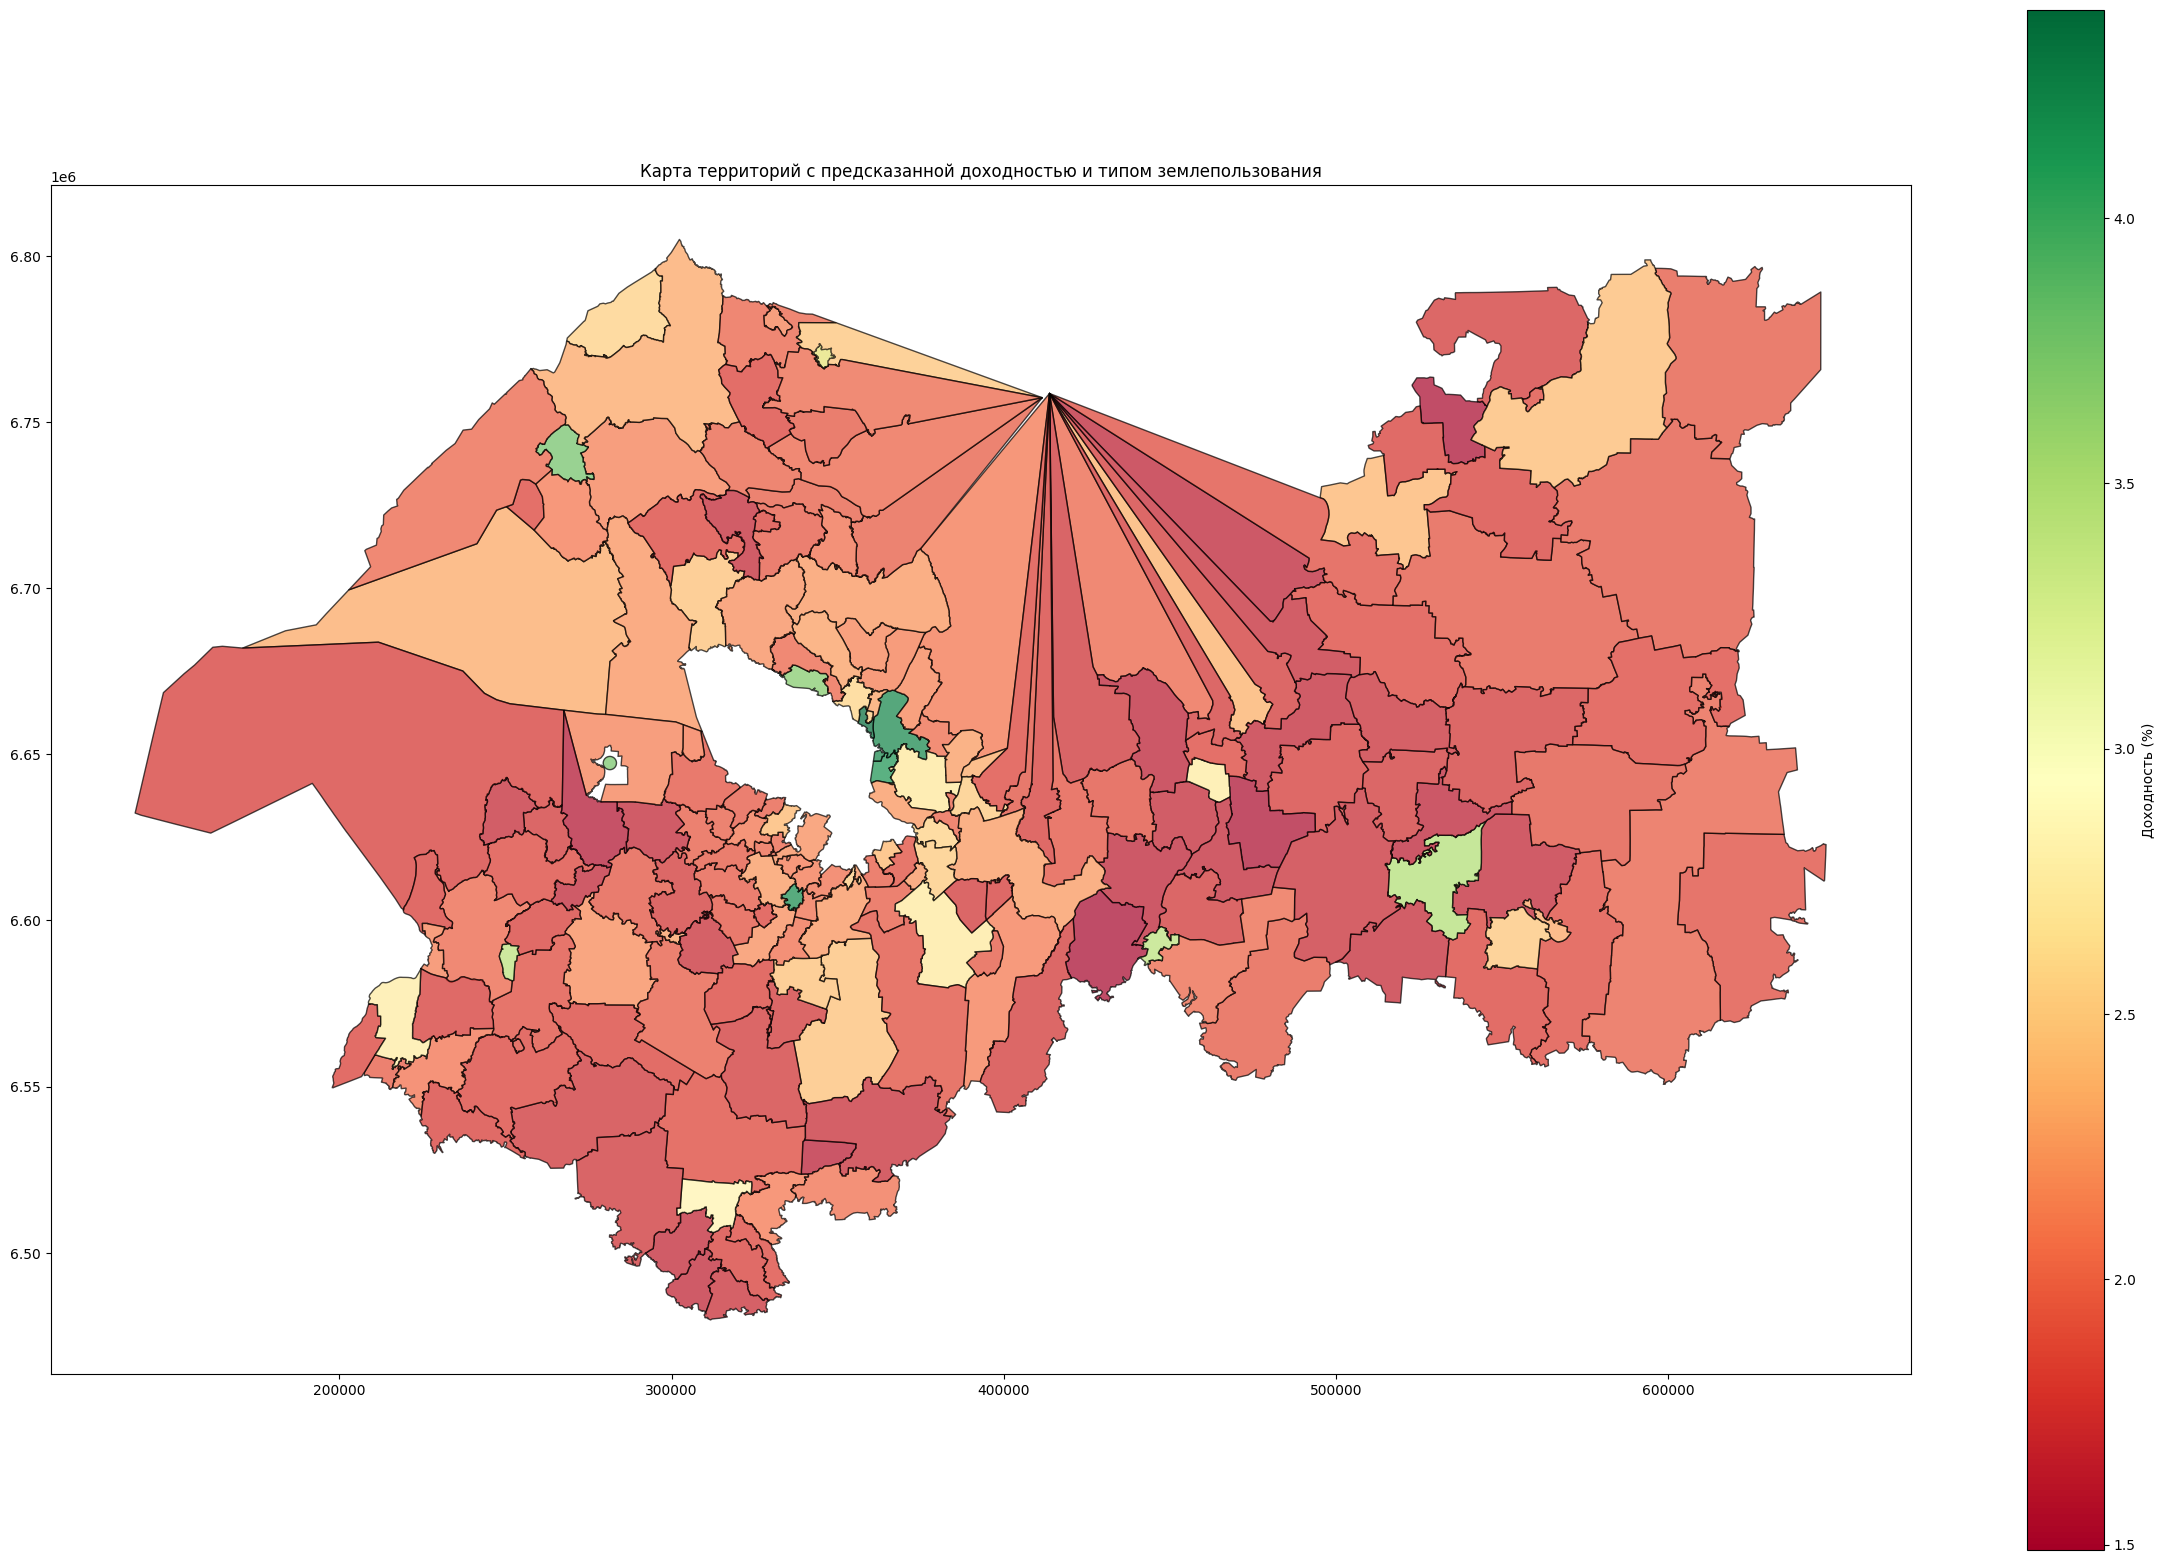

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Предполагается, что predict_investment_potential определена ранее
# Например:
# def predict_investment_potential(idx):
#     # Заглушка для примера
#     return {'Residential': 0.75, 'Commercial': 0.60, 'Industrial': 0.45}

# Функция предсказания для всех территорий
def get_top_territories(gdf, model, le, features, top_n=5):
    territory_scores = []
    
    for idx in range(len(gdf)):
        territory_name = gdf.loc[idx, 'name']
        predictions = predict_investment_potential(idx)
        max_score = max(predictions.values())
        best_land_use = max(predictions, key=predictions.get)
        territory_scores.append({
            'territory_id': gdf.loc[idx, 'territory_id'],
            'name': territory_name,
            'max_investment_score': max_score,
            'best_land_use': best_land_use
        })
    
    # Преобразуем в DataFrame и сортируем
    scores_df = pd.DataFrame(territory_scores)
    top_territories = scores_df.sort_values(by='max_investment_score', ascending=False).head(top_n)
    
    # Добавляем результаты в исходный gdf
    gdf_with_scores = gdf.merge(scores_df[['territory_id', 'max_investment_score', 'best_land_use']], 
                               on='territory_id', how='left')
    
    return top_territories, gdf_with_scores

# Получаем топ-5 и обновленный gdf
top_5, gdf_updated = get_top_territories(gdf, model, le, features, top_n=5)
print("Топ-5 территорий по инвестиционной привлекательности:")
print(top_5)

# Визуализация предсказаний на карте
fig, ax = plt.subplots(figsize=(30, 20))
gdf_updated.plot(column='max_investment_score', ax=ax, cmap='RdYlGn', legend=True, 
                 edgecolor='black', alpha=0.7, legend_kwds={'label': "Доходность (%)"})

plt.title("Карта территорий с предсказанной доходностью и типом землепользования")

# Аннотации
for idx, row in gdf_updated.iterrows():
    centroid = row['geometry'].centroid
    plt.annotate(f"{row['max_investment_score']:.2f}\n{row['best_land_use']}", 
                 xy=centroid.coords[0], 
                 ha='center', va='center', fontsize=8, 
                 bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))

plt.axis('off')
plt.show()

# SHAP-анализ (оставляем как есть, предполагая, что X_new и model определены)
explainer = shap.TreeExplainer(model)
new_territory = X_new.iloc[[0]]  
shap_values_new = explainer.shap_values(new_territory.values)

# Бар-график SHAP
plt.figure(figsize=(12, 6))
plt.bar(new_territory.columns, shap_values_new[0], 
        color=['green' if x > 0 else 'red' for x in shap_values_new[0]])
plt.axhline(0, color='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Признаки")
plt.ylabel("Вклад в доходность (%)")
plt.title(f"Влияние признаков на доходность для территории 0 ({gdf_updated['best_land_use'].iloc[0]})")
plt.tight_layout()
plt.show()

shap.waterfall_plot(shap.Explanation(values=shap_values_new[0], 
                                    base_values=explainer.expected_value, 
                                    data=new_territory.iloc[0], 
                                    feature_names=new_territory.columns.tolist()))

# ML

In [42]:
# 1. Создание и обучение модели
# Инициализация LabelEncoder с известными значениями LandUseType
le = LabelEncoder()
le.fit(['residential', 'recreation', 'special', 'industrial', 
        'agriculture', 'transport', 'business', 'basic', 
        'residential_individual', 'residential_lowrise', 
        'residential_midrise', 'residential_multistorey',
        'mixed_use'])  # Обучаем на строковых метках

# Генерация данных для обучения модели
np.random.seed(42)
n_samples = 10000
data = {
    'LandUseType': np.random.choice(['residential', 'recreation', 'special', 'industrial', 
                                     'agriculture', 'transport', 'business', 'basic', 
                                     'residential_individual', 'residential_lowrise', 'residential_midrise', 
                                     'residential_multistorey', 'mixed_use'], n_samples),

    'LocationScore': np.random.uniform(1, 10, n_samples),
    'AreaTotal': np.random.uniform(100, 20000, n_samples),
    'AreaResidential': np.random.uniform(0, 15000, n_samples),
    'AreaCommercial': np.random.uniform(0, 10000, n_samples),
    'Infrastructure': np.random.uniform(1, 10, n_samples),
    'RoadDevelopment': np.random.uniform(1, 10, n_samples),
    'EcoRestrictions': np.random.uniform(0, 5, n_samples),
    'PopulationDensity': np.random.uniform(50, 5000, n_samples),
    'AvgIncomeLevel': np.random.uniform(20000, 100000, n_samples),
    'DistanceToCenter': np.random.uniform(0.5, 20, n_samples),
    'MarketDemand': np.random.uniform(1, 10, n_samples),
    'Taxes': np.random.uniform(1000, 5000, n_samples),
    'Income': np.random.uniform(5000, 20000, n_samples),
    'ProvisionLevel': np.random.uniform(1, 10, n_samples)
}

land_use_effect = {
    'residential': 0.7,  # Жилая зона – средняя привлекательность, стабильный спрос
    'recreation': 0.4,  # Рекреационная зона – низкая доходность, но ценно для экологии и туризма
    'special': 0.3,  # Особого назначения – ограниченное использование, низкая инвестиционная привлекательность
    'industrial': 1.2,  # Промышленная зона – стабильный доход, но зависимость от экономики
    'agriculture': 0.5,  # Сельскохозяйственная зона – низкая доходность, но долгосрочные инвестиции
    'transport': 0.8,  # Транспортная зона – средняя привлекательность, но зависимость от инфраструктуры
    'business': 2.0,  # Общественно-деловая зона – высокая инвестиционная привлекательность
    'basic': 0.2,  # Базовая зона – малоперспективная для инвестиций
    'residential_individual': 0.9,  # ИЖС – средняя доходность, зависит от спроса
    'residential_lowrise': 1.0,  # Малоэтажная жилая зона – хороший баланс доходности и стабильности
    'residential_midrise': 1.2,  # Среднеэтажная жилая зона – выше привлекательность, плотность застройки
    'residential_multistorey': 1.5,  # Многоэтажная жилая зона – высокая инвестиционная привлекательность
    'mixed_use': 1.8  # Многофункциональная зона – высокая привлекательность за счет гибкости использования
}


# Формула доходности с учетом новых признаков
data['InvestmentReturn'] = (
    0.4 * data['LocationScore'] +
    0.3 * data['Infrastructure'] +
    0.2 * data['RoadDevelopment'] -
    0.2 * data['EcoRestrictions'] +
    0.1 * np.log(data['PopulationDensity']) +
    0.2 * data['AvgIncomeLevel'] / 10000 -
    0.3 * data['DistanceToCenter'] +
    0.3 * data['MarketDemand'] +
    0.3 * (data['AreaTotal'] / 10000) +
    0.2 * (data['AreaResidential'] / 10000) +
    0.4 * (data['AreaCommercial'] / 10000) -
    0.3 * (data['Taxes'] / 1000) +
    0.4 * (data['Income'] / 10000) +
    0.2 * data['ProvisionLevel'] +
    [land_use_effect[land] for land in data['LandUseType']] +
    np.random.normal(0, 0.5, n_samples)
)
df = pd.DataFrame(data)

# Подготовка данных для обучения
df['LandUseType'] = le.transform(df['LandUseType'])  # Кодируем строковые метки в числовые
X = df.drop('InvestmentReturn', axis=1)
y = df['InvestmentReturn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение модели
model = XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1, alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Оценка
print(f"Точность на обучающей выборке (R²): {model.score(X_train, y_train):.3f}")
print(f"Точность на тестовой выборке (R²): {model.score(X_test, y_test):.3f}")

Точность на обучающей выборке (R²): 0.862
Точность на тестовой выборке (R²): 0.837


In [47]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import shap
from shapely.geometry import Polygon

# Подготовка имеющегося GeoDataFrame
territory_gdf = split_gdf.copy()  # Копируем, чтобы избежать изменений в оригинале

# Добавляем необходимые атрибуты для модели (случайные данные для примера)
np.random.seed(42)  # Фиксируем генератор случайных чисел для воспроизводимости

territory_gdf['LandUseType'] = np.random.choice(['residential', 'recreation', 'special', 'industrial', 
        'agriculture', 'transport', 'business', 'basic', 
        'residential_individual', 'residential_lowrise', 
        'residential_midrise', 'residential_multistorey',
        'mixed_use'], len(territory_gdf))

territory_gdf['LocationScore'] = np.random.uniform(1, 10, len(territory_gdf))
territory_gdf['AreaTotal'] = np.random.uniform(100, 20000, len(territory_gdf))
territory_gdf['AreaResidential'] = np.random.uniform(0, 15000, len(territory_gdf))
territory_gdf['AreaCommercial'] = np.random.uniform(0, 10000, len(territory_gdf))
territory_gdf['Infrastructure'] = np.random.uniform(1, 10, len(territory_gdf))
territory_gdf['RoadDevelopment'] = np.random.uniform(1, 10, len(territory_gdf))
territory_gdf['EcoRestrictions'] = np.random.uniform(0, 5, len(territory_gdf))
territory_gdf['PopulationDensity'] = np.random.uniform(50, 5000, len(territory_gdf))
territory_gdf['AvgIncomeLevel'] = np.random.uniform(20000, 100000, len(territory_gdf))
territory_gdf['DistanceToCenter'] = np.random.uniform(0.5, 20, len(territory_gdf))
territory_gdf['MarketDemand'] = np.random.uniform(1, 10, len(territory_gdf))
territory_gdf['Taxes'] = np.random.uniform(1000, 5000, len(territory_gdf))
territory_gdf['Income'] = np.random.uniform(5000, 20000, len(territory_gdf))
territory_gdf['ProvisionLevel'] = np.random.uniform(1, 10, len(territory_gdf))

# Кодирование LandUseType для модели
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
territory_gdf['LandUseType'] = le.fit_transform(territory_gdf['LandUseType'])

feature_columns = ['LandUseType', 'LocationScore', 'AreaTotal', 'AreaResidential', 
                   'AreaCommercial', 'Infrastructure', 'RoadDevelopment', 
                   'EcoRestrictions', 'PopulationDensity', 'AvgIncomeLevel', 
                   'DistanceToCenter', 'MarketDemand', 'Taxes', 'Income', 'ProvisionLevel']

# Убираем ненужные столбцы
X_new = territory_gdf[feature_columns]
investment_returns = model.predict(X_new)

# Добавляем предсказания в GeoDataFrame
territory_gdf['InvestmentReturn'] = investment_returns


# Добавляем предсказания в GeoDataFrame
territory_gdf['InvestmentReturn'] = investment_returns

# Декодируем LandUseType обратно для визуализации
territory_gdf['LandUseType'] = le.inverse_transform(territory_gdf['LandUseType'])

# 🔹 Визуализация предсказаний на карте
fig, ax = plt.subplots(figsize=(30, 20))
territory_gdf.plot(column='InvestmentReturn', ax=ax, cmap='RdYlGn', legend=True, 
                    edgecolor='black', alpha=0.7, legend_kwds={'label': "Доходность (%)"})

plt.title("Карта территорий с предсказанной доходностью и типом землепользования")

# Аннотации
for idx, row in territory_gdf.iterrows():
    centroid = row['geometry'].centroid
    plt.annotate(f"{row['InvestmentReturn']:.2f}%\n{row['LandUseType']}", 
                 xy=centroid.coords[0], 
                 ha='center', va='center', fontsize=8, 
                 bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))

plt.axis('off')
plt.show()

# 🔹 SHAP-анализ для объяснения модели
explainer = shap.TreeExplainer(model)

# Анализ SHAP для первой территории
new_territory = X_new.iloc[[0]]  
shap_values_new = explainer.shap_values(new_territory.values)

# Бар-график SHAP
plt.figure(figsize=(12, 6))
plt.bar(new_territory.columns, shap_values_new[0], 
        color=['green' if x > 0 else 'red' for x in shap_values_new[0]])
plt.axhline(0, color='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Признаки")
plt.ylabel("Вклад в доходность (%)")
plt.title(f"Влияние признаков на доходность для территории 0 ({territory_gdf['LandUseType'].iloc[0]})")
plt.tight_layout()
plt.show()

shap.waterfall_plot(shap.Explanation(values=shap_values_new[0], 
                                     base_values=explainer.expected_value, 
                                     data=new_territory.iloc[0], 
                                     feature_names=new_territory.columns.tolist()))

# Вывод SHAP-вкладов
print("\nВклад признаков в прогноз для новой территории:")
for feature, shap_val in zip(new_territory.columns, shap_values_new[0]):
    print(f"{feature}: {shap_val:.3f}")


NameError: name 'split_gdf' is not defined

In [8]:
# mo_territories_gdf = gpd.read_parquet('data/gnn_data/territories.parquet')
# mo_territories_gdf

In [9]:
# block = gpd.read_parquet('data/gnn_data/189_blocks.parquet')
# block

In [10]:
# import geopandas as gpd
# import pandas as pd
# import os

# # Путь к файлам Parquet
# parquet_dir = "data/gnn_data"

# # Целевая CRS (можно заменить на нужную)
# target_crs = "EPSG:32636"

# # Создаем пустой список для хранения загруженных геоданных
# all_blocks = []

# # Проходим по всем territory_id
# for territory_id in mo_territories_gdf.index:
#     parquet_path = os.path.join(parquet_dir, f"{territory_id}_blocks.parquet")
    
#     # Проверяем, существует ли файл
#     if os.path.exists(parquet_path):
#         try:
#             block_gdf = gpd.read_parquet(parquet_path)
            
#             # Проверяем, есть ли у GeoDataFrame CRS, и приводим к целевой системе координат
#             if block_gdf.crs and block_gdf.crs != target_crs:
#                 block_gdf = block_gdf.to_crs(target_crs)

#             all_blocks.append(block_gdf)
#         except Exception as e:
#             print(f"Ошибка при загрузке {parquet_path}: {e}")
#     else:
#         print(f"Файл не найден: {parquet_path}")

# # Объединяем все загруженные файлы в один GeoDataFrame
# if all_blocks:
#     merged_gdf = gpd.GeoDataFrame(pd.concat(all_blocks, ignore_index=True), crs=target_crs)
#     print("Объединенный GeoDataFrame создан успешно!")
# else:
#     merged_gdf = gpd.GeoDataFrame()
#     print("Не удалось загрузить ни одного файла.")

# merged_gdf